In [291]:
import deepinv as dinv
import torch
import torch.nn.functional as F
import time

### Computing the filter associated to $A^\top A$ when $A$ is a convolution operator

Blur filter shape: torch.Size([1, 1, 35, 35])
h_AtA shape: torch.Size([1, 1, 69, 69])
Diff shape: torch.Size([1, 1, 512, 512])
Norm of difference: tensor(0.0008)
Max value of difference: 0.000005


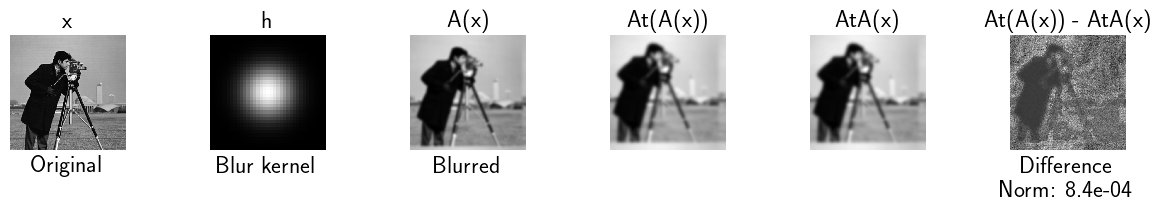

In [388]:
x = dinv.utils.load_example('cameraman.png', grayscale=True)

C, H, W = x.shape[1:]

blur_filter = dinv.physics.blur.gaussian_blur(sigma=(5, 5), angle=0.0)
print(f'Blur filter shape: {blur_filter.shape}')
blur_filter_t = torch.flip(blur_filter, [2, 3])  # transposed kernel (flipped spatially)

K = blur_filter.shape[-1]  # half size of the kernel

# Convolution A(x)
def A(x):
    #C, H, W = x.shape[1:]
    x_padded = F.pad(x, (K, K, K, K), mode='circular')  # circular padding on the last two dimensions (padding_left,padding_right, padding_top,padding_bottom)
    output = F.conv2d(x_padded, blur_filter)
    output = output[:, :, K:H+K, K:W+K]  # crop to original size
    return output

# Convolution At(y)
def At(y):
    #C, H, W = y.shape[1:]
    y_padded = F.pad(y, (K, K, K, K), mode='circular')
    output = F.conv2d(y_padded, blur_filter_t)
    output = output[:, :, K:H+K, K:W+K]  # crop to original size
    return output

# AtA(x)
h_AtA = F.conv2d(blur_filter, blur_filter_t, padding=K-1)  # zero padding of size K-1 for 'full' convolution
K_AtA = h_AtA.shape[-1]
print(f'h_AtA shape: {h_AtA.shape}')

def AtA(x):
    #C, H, W = x.shape[1:]
    x_padded = F.pad(x, (K_AtA, K_AtA, K_AtA, K_AtA), mode='circular')
    output = F.conv2d(x_padded, h_AtA)
    output = output[:, :, K_AtA:H+K_AtA, K_AtA:W+K_AtA]  # crop to original size
    return output

diff = At(A(x)) - AtA(x)
print('Diff shape:', diff.shape)
print('Norm of difference:', torch.norm(diff))
print(f'Max value of difference: {torch.max(torch.abs(diff)):.6f}')

dinv.utils.plot([x, blur_filter, A(x), At(A(x)), AtA(x), diff], titles=['x', 'h', 'A(x)', 'At(A(x))', 'AtA(x)', 'At(A(x)) - AtA(x)'], subtitles=['Original', 'Blur kernel', 'Blurred', '', '', 'Difference\nNorm: {:.1e}'.format(torch.norm(diff))], cmap='gray', rescale_mode='min_max', tight=False)

In [391]:
# Speed comparison:

start = time.time()
At(A(x))
time1 = time.time() - start
print(f"At(A) took {time1:.4f} seconds")

start = time.time()
AtA(x)
time2 = time.time() - start
print(f"AtA took {time2:.4f} seconds")

print(f"AtA is faster than At(A) by a factor: {time1/time2:.2f}")

At(A) took 0.1277 seconds
AtA took 0.0895 seconds
AtA is faster than At(A) by a factor: 1.43


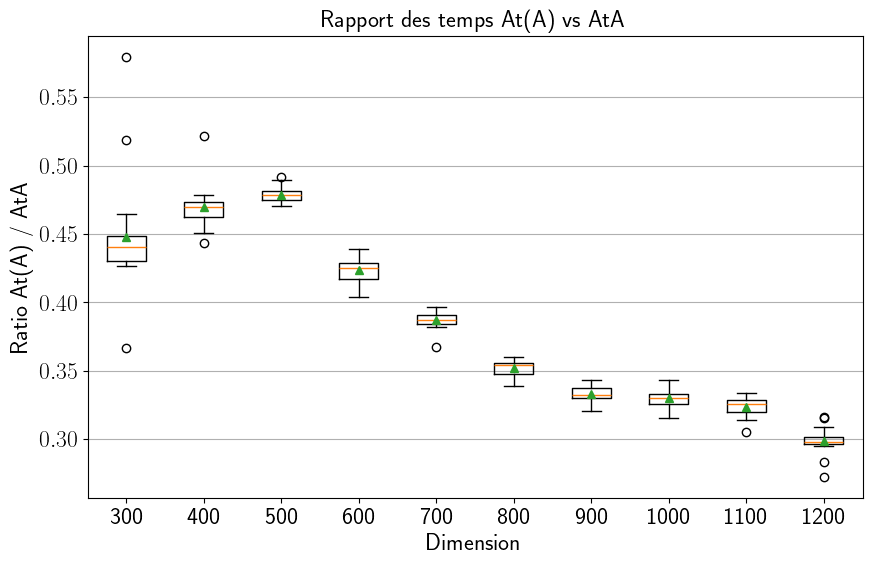

In [ ]:
import matplotlib.pyplot as plt
# Speed comparison:

dims = [300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200]
n_trials = 20

ratios = {dim: [] for dim in dims}

for dim in dims:
    for _ in range(n_trials):
        x = torch.randn(1, 1, dim, dim)

        start = time.time()
        At(A(x))
        t1 = time.time() - start

        start = time.time()
        AtA(x)
        t2 = time.time() - start

        ratios[dim].append(t1 / t2)

# Préparer les données pour le boxplot
data = [ratios[dim] for dim in dims]
labels = [str(dim) for dim in dims]

plt.figure(figsize=(10, 6))
plt.boxplot(data, tick_labels=labels, showmeans=True)
plt.ylabel("Ratio At(A) / AtA")
plt.xlabel("Dimension")
plt.title("Time ratios At(A) vs AtA")
plt.grid(axis='y')
plt.show()

### Is this normal ?

If the image is of size $H \times W$, and the blur kernel of size $k \times k$, the number of operations are:
- $A x$: $H\cdot W\cdot k^2$ operations,
- $A^\top Ax$: $H \cdot W \cdot k^2$ operations.

The total is $2 H \cdot W \cdot k^2$.

The kernel associated to $A^\top A$ is of size $2k - 1$ and therefore
- $A^T A x$: $H \cdot W \cdot (2k-1)^2 = H\cdot W\cdot (4k^2 - 4k +1) \approx 4H\cdot W \cdot k^2$

### With FFTs ?

The method where we store $h_{A^\top A}$ should be faster, as no matter the size of the convolution kernel, with FFTs the speed of a convolution is $O(HW \log(HW))$. Therefore $A^\top A(x)$ should be twice as fast as $A^\top (A(x))$ for every image size.

Norm of A(x) - A_x: 76.814377
Norme différence: tensor(0.8158)
Max différence: tensor(0.0095)


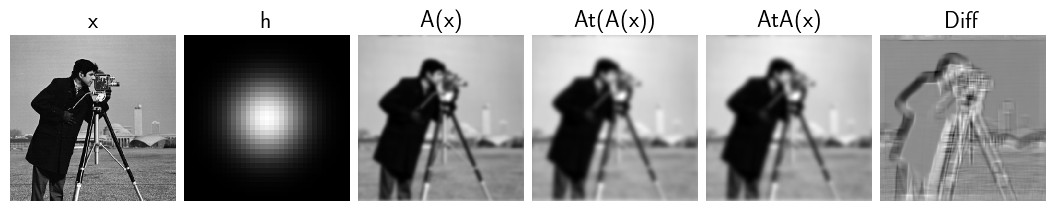

In [365]:
import torch.fft as fft

def fft_conv2d(x, kernel):
    """Convolution 2D via FFT"""
    _, _, H, W = x.shape
    # Zero-pad kernel to image size
    kernel_padded = torch.zeros_like(x)
    kh, kw = kernel.shape[-2:]
    kernel_padded[:, :, :kh, :kw] = kernel
    kernel_padded = torch.roll(kernel_padded, shifts=(-kh // 2, -kw // 2), dims=(-2, -1))
    X = fft.fft2(x)
    Kf = fft.fft2(kernel_padded)
    Y = fft.ifft2(X * Kf).real
    return Y

x = dinv.utils.load_example('cameraman.png', grayscale=True)

# At(A(x)) via FFT
A_x = fft_conv2d(x, blur_filter)

print(f'Norm of A(x) - A_x: {torch.norm(A(x) - A_x):.6f}')

At_A_x = fft_conv2d(A_x, blur_filter_t)

# AtA(x) via FFT
h_AtA = fft_conv2d(blur_filter, blur_filter_t)
AtA_x = fft_conv2d(x, h_AtA)

diff = At_A_x - AtA_x
print('Norme différence:', torch.norm(diff))
print('Max différence:', torch.max(torch.abs(diff)))

dinv.utils.plot([x, blur_filter, A_x, At_A_x, AtA_x, diff], titles=['x', 'h', 'A(x)', 'At(A(x))', 'AtA(x)', 'Diff'], cmap='gray', rescale_mode='min_max')

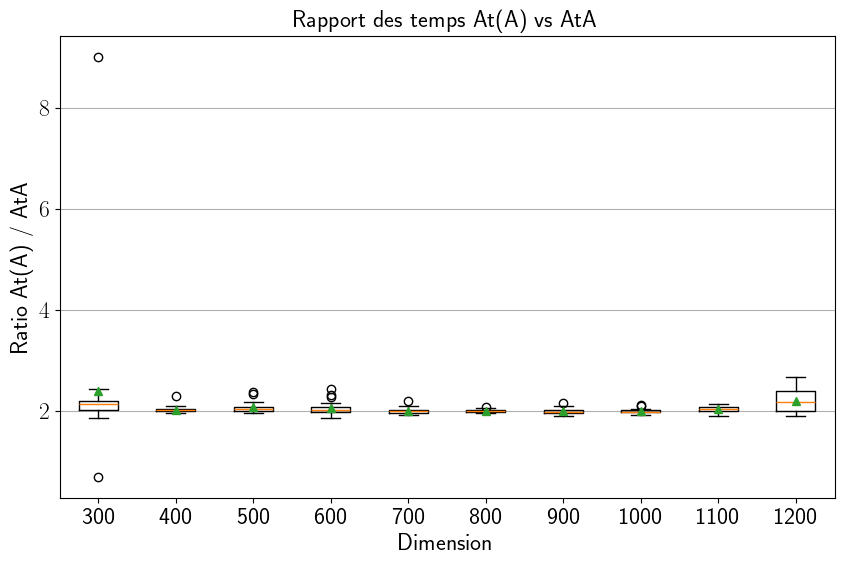

In [ ]:
import matplotlib.pyplot as plt
# Speed comparison:

dims = [300, 400, 500, 600, 700, 800, 900, 1000, 1100, 1200]
n_trials = 20

ratios = {dim: [] for dim in dims}

for dim in dims:
    for _ in range(n_trials):
        x = torch.randn(1, 1, dim, dim)

        start = time.time()
        fft_conv2d(fft_conv2d(x, blur_filter), blur_filter_t)
        t1 = time.time() - start

        start = time.time()
        fft_conv2d(x, h_AtA)
        t2 = time.time() - start

        ratios[dim].append(t1 / t2)

# Préparer les données pour le boxplot
data = [ratios[dim] for dim in dims]
labels = [str(dim) for dim in dims]

plt.figure(figsize=(10, 6))
plt.boxplot(data, tick_labels=labels, showmeans=True)
plt.ylabel("Ratio At(A) / AtA")
plt.xlabel("Dimension")
plt.title("Time ratios At(A) vs AtA")
plt.grid(axis='y')
plt.show()

### Combined with downsampling ?

16 16 16 16


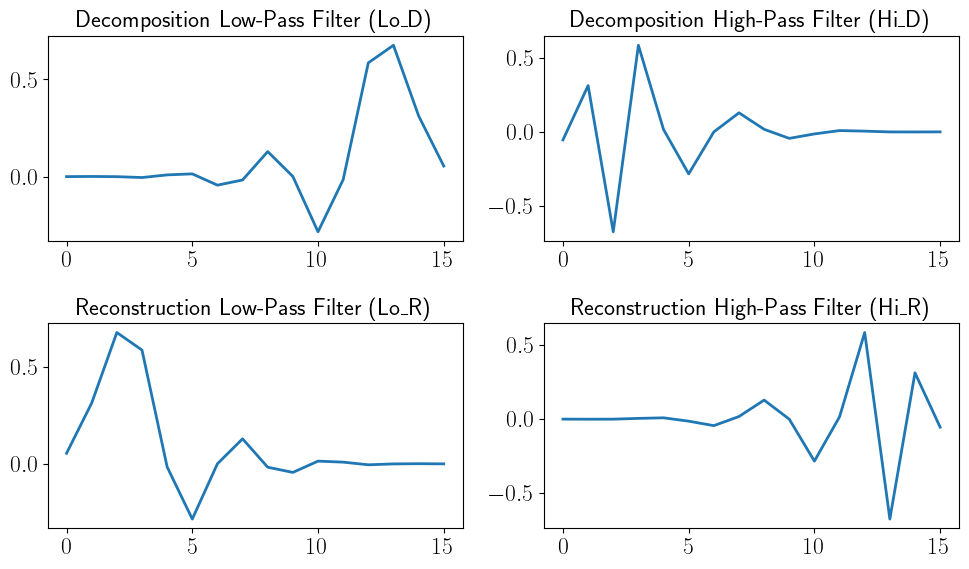

In [364]:
import pywt
import matplotlib.pyplot as plt

wavelet = pywt.Wavelet('db8')   # Daubechies-16 wavelet
Lo_D, Hi_D = wavelet.dec_lo, wavelet.dec_hi  # decomposition filters
Lo_R, Hi_R = wavelet.rec_lo, wavelet.rec_hi  # reconstruction filters

print(len(Lo_D), len(Hi_D), len(Lo_R), len(Hi_R))

plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.plot(Lo_D)
plt.title('Decomposition Low-Pass Filter (Lo_D)')
plt.subplot(2, 2, 2)
plt.plot(Hi_D)
plt.title('Decomposition High-Pass Filter (Hi_D)')
plt.subplot(2, 2, 3)
plt.plot(Lo_R)
plt.title('Reconstruction Low-Pass Filter (Lo_R)')
plt.subplot(2, 2, 4)
plt.plot(Hi_R)
plt.title('Reconstruction High-Pass Filter (Hi_R)')
plt.tight_layout()
plt.show()

torch.Size([1, 1, 16, 16])
torch.Size([1, 1, 16, 16])


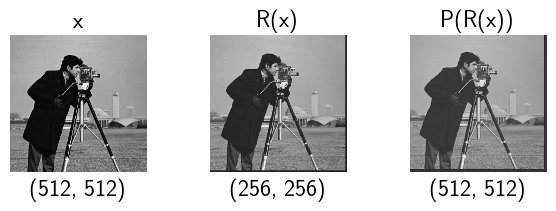

In [367]:
def R(x):
    # Restriction operator (returns the approximation coefficients)
    filter = torch.outer(torch.tensor(Lo_D), torch.tensor(Lo_D)).unsqueeze(0).unsqueeze(0)
    print(filter.shape)
    return F.conv2d(x, filter, padding=7, stride=2)

def P(y):
    # Prolongation operator (upsamples the coefficients)
    filter = torch.outer(torch.tensor(Lo_R), torch.tensor(Lo_R)).unsqueeze(0).unsqueeze(0)
    print(filter.shape)
    return F.conv_transpose2d(y, filter, padding=7, stride=2)

x = dinv.utils.load_example('cameraman.png', grayscale=True)

y = R(x)
z = P(y)

subtitles=[f'{tuple(x.shape[-2:])}', f'{tuple(y.shape[-2:])}', f'{tuple(z.shape[-2:])}']

dinv.utils.plot([x, y,z], titles=['x', 'R(x)', 'P(R(x))'], subtitles=subtitles, cmap='gray', tight=False)

torch.Size([1, 1, 16, 16])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 16, 16])
torch.Size([1, 1, 16, 16])
torch.Size([1, 1, 256, 256])
torch.Size([1, 1, 16, 16])
torch.Size([1, 1, 16, 16])
torch.Size([1, 1, 16, 16])
torch.Size([1, 1, 16, 16])


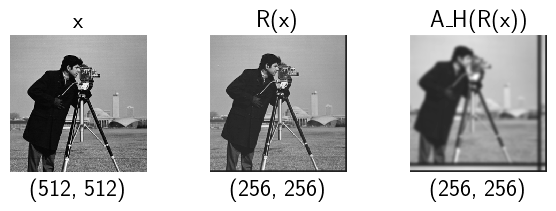

In [363]:
def A_H(x):
    return R(A(P(x)))

a = R(x)
print(a.shape)

print(A_H(a).shape)

dinv.utils.plot([x, a, A_H(a)], titles=['x', 'R(x)', 'A_H(R(x))'], subtitles=[f'{tuple(x.shape[-2:])}', f'{tuple(a.shape[-2:])}', f'{tuple(A_H(a).shape[-2:])}'], cmap='gray', tight=False)

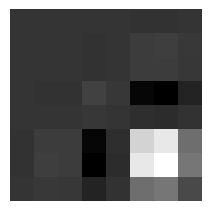

Fine filter shape: torch.Size([1, 1, 15, 15])
Coarse filter shape: torch.Size([1, 1, 8, 8])
Details filter shape: torch.Size([1, 1, 8, 8])


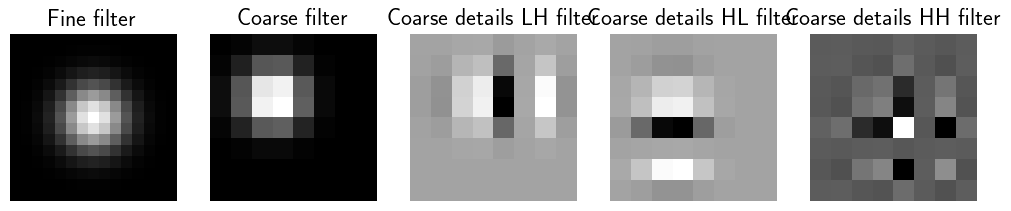

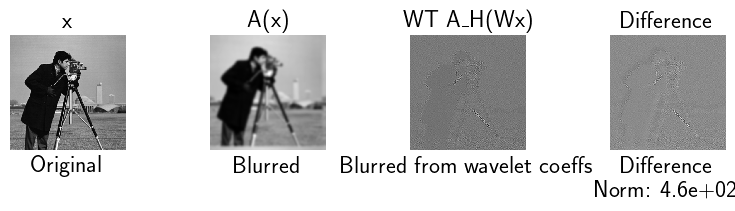

In [385]:
# Code de Nils

def coarse_blur_filter(fine_filter, downsampling_filter):
    in_filt = fine_filter

    # ensure filter is at least 3x3
    if in_filt.shape[-2] <= 3:
        in_filt = F.pad(in_filt, (0, 0, 1, 1))
    if in_filt.shape[-1] <= 3:
        in_filt = F.pad(in_filt, (1, 1, 0, 0))

    # left, right, top, bottom padding to perform valid convolution
    df_shape = downsampling_filter.shape
    pad_size = (df_shape[-2] // 2,) * 2 + (df_shape[-1] // 2,) * 2
    pf = F.pad(in_filt, pad_size)

    # downsample the blur filter
    df_groups = downsampling_filter.repeat([pf.shape[1]] + [1] * (len(pf.shape) - 1))
    coarse_filter = F.conv2d(
        pf, df_groups, groups=pf.shape[1], padding="valid"
    )
    coarse_filter = coarse_filter[:, :, ::2, ::2]
    coarse_filter = coarse_filter / torch.sum(coarse_filter) * torch.sum(in_filt)

    return coarse_filter

fine_filter = dinv.physics.blur.gaussian_blur(sigma=(2, 2), angle=0.0)

ds_kernel = torch.tensor([[1., 2., 1.],
                          [2., 4., 2.],
                          [1., 2., 1.]])

wavelet = pywt.Wavelet('db4')   # Daubechies-16 wavelet
Lo_D, Hi_D = wavelet.dec_lo, wavelet.dec_hi  # decomposition filters
Lo_R, Hi_R = wavelet.rec_lo, wavelet.rec_hi  # reconstruction filters

downsampling_filter = torch.outer(torch.tensor(Lo_D), torch.tensor(Lo_D)).unsqueeze(0).unsqueeze(0)
dinv.utils.plot(downsampling_filter)

details_filter_LH = torch.outer(torch.tensor(Lo_D), torch.tensor(Hi_D)).unsqueeze(0).unsqueeze(0)
details_filter_HL = torch.outer(torch.tensor(Hi_D), torch.tensor(Lo_D)).unsqueeze(0).unsqueeze(0)
details_filter_HH = torch.outer(torch.tensor(Hi_D), torch.tensor(Hi_D)).unsqueeze(0).unsqueeze(0)

coarse_filter = coarse_blur_filter(fine_filter, downsampling_filter)
coarse_details_filter_LH = coarse_blur_filter(fine_filter, details_filter_LH)
coarse_details_filter_HL = coarse_blur_filter(fine_filter, details_filter_HL)
coarse_details_filter_HH = coarse_blur_filter(fine_filter, details_filter_HH)

print("Fine filter shape:", fine_filter.shape)
print("Coarse filter shape:", coarse_filter.shape)
print("Details filter shape:", coarse_details_filter_HH.shape)

dinv.utils.plot([fine_filter, coarse_filter, coarse_details_filter_LH, coarse_details_filter_HL, coarse_details_filter_HH], titles=['Fine filter', 'Coarse filter', 'Coarse details LH filter', 'Coarse details HL filter', 'Coarse details HH filter'], cmap='gray', rescale_mode='min_max', tight=False)

# Is it equivalent to apply A to x than to apply the (A_H) to Wx ?
import ptwt

x = dinv.utils.load_example('cameraman.png', grayscale=True)

Wx = ptwt.wavedec2(x, wavelet='db4', level=1)

A_x = A(x)
A_x_approx = F.conv2d(Wx[0], coarse_filter, padding='same')
A_x_details_LH = F.conv2d(Wx[1][0], coarse_details_filter_LH, padding='same')
A_x_details_HL = F.conv2d(Wx[1][1], coarse_details_filter_HL, padding='same')
A_x_details_HH = F.conv2d(Wx[1][2], coarse_details_filter_HH, padding='same')

A_x_wavelet = ptwt.waverec2((A_x_approx, (A_x_details_LH, A_x_details_HL, A_x_details_HH)), wavelet='db4')

dinv.utils.plot([x, A_x, A_x_wavelet, A_x - A_x_wavelet], titles=['x', 'A(x)', 'WT A_H(Wx)', 'Difference'], subtitles=['Original', 'Blurred', 'Blurred from wavelet coeffs', 'Difference\nNorm: {:.1e}'.format(torch.norm(A_x - A_x_wavelet))], cmap='gray', rescale_mode='min_max', tight=False)

